# Step 3: VQE Optimization with RF Error Mitigation

Plugs the trained RF model into a VQE optimization loop and compares:
- **Ideal VQE**: noiseless simulation (ground truth)
- **Noisy VQE**: FakeLima noise, no correction
- **RF-mitigated VQE**: FakeLima noise + RF correction at each iteration

Reproduces the key result from Section C / Fig. 5(b) of:
> Liao et al. *Machine Learning for Practical Quantum Error Mitigation*,
> Nature Machine Intelligence 6, 594–604 (2024). arXiv:2309.17368

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import joblib

from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.primitives import StatevectorEstimator
from qiskit import transpile

from qiskit_aer.primitives import Estimator as AerEstimatorV1
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeLimaV2

print('All imports OK')

All imports OK


## 1. Setup: Hamiltonian, Ansatz, Noise, Estimators

Recreates the exact same setup as the data generation notebook.

In [2]:
# ── H2 Hamiltonian at equilibrium (0.735 Angstrom) ────────────────────────────
PAULI_LABELS = ['II', 'IZ', 'ZI', 'ZZ', 'XX']
H2_COEFFS    = [-1.0523732, 0.39793742, -0.39793742, -0.01128010, -0.18093120]
pauli_ops    = [SparsePauliOp(p) for p in PAULI_LABELS]

# Exact ground state energy by diagonalization
def exact_energy(coeffs):
    c0, c1, c2, c3, c4 = coeffs
    H = np.zeros((4, 4))
    H[0,0] = c0 + c1 + c2 + c3
    H[1,1] = c0 - c1 + c2 - c3
    H[2,2] = c0 + c1 - c2 - c3
    H[3,3] = c0 - c1 - c2 + c3
    H[0,3] = H[3,0] = c4
    H[1,2] = H[2,1] = c4
    return np.min(np.linalg.eigvalsh(H))

E_EXACT = exact_energy(H2_COEFFS)
print(f'Exact ground state energy: {E_EXACT:.6f} Ha')

# ── Ansatz (must match data generation) ───────────────────────────────────────
ansatz = TwoLocal(num_qubits=2, rotation_blocks='ry',
                  entanglement_blocks='cx', entanglement='linear', reps=3)
num_params = ansatz.num_parameters
print(f'Ansatz parameters: {num_params}')

# Transpile to basis gates
transpiled_ansatz = transpile(ansatz, basis_gates=['rz', 'sx', 'cx', 'x'],
                              optimization_level=1)
print(f'Transpiled depth: {transpiled_ansatz.depth()}')

# ── Noise model and estimators ────────────────────────────────────────────────
backend = FakeLimaV2()
noise_model = NoiseModel.from_backend(backend)

ideal_estimator = StatevectorEstimator()

noisy_estimator = AerEstimatorV1()
noisy_estimator.set_options(noise_model=noise_model, shots=10000)

print('Estimators ready.')

Exact ground state energy: -1.857275 Ha
Ansatz parameters: 8
Transpiled depth: 19
Estimators ready.


## 2. Load RF Model and Define Correction

Feature vector (13 columns) must exactly match training:

`[noisy_val, x_q0, x_q1, z_q0, z_q1, n_2q, n_sx, T1_q0*m0, T2_q0*m0, ro_q0*m0, T1_q1*m1, T2_q1*m1, ro_q1*m1]`

where `m0`, `m1` are masks derived from the symplectic encoding.

In [3]:
# Load trained RF
rf = joblib.load('rf_mlqem.joblib')
print(f'RF model loaded: {rf.n_estimators} trees, {rf.n_features_in_} features')

# Circuit features (same as training)
N_2Q = 3
N_SX = 8

# Per-qubit noise parameters from FakeLimaV2
props = backend.properties()
QUBIT_NOISE = {}
for q in range(2):
    QUBIT_NOISE[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }
    print(f"  Qubit {q}: T1={QUBIT_NOISE[q]['T1']:.1f}us  "
          f"T2={QUBIT_NOISE[q]['T2']:.1f}us  "
          f"ro={QUBIT_NOISE[q]['readout_error']:.4f}")

# Symplectic encoding
def pauli_to_symplectic(label):
    p = Pauli(label)
    return np.concatenate([p.x.astype(int), p.z.astype(int)])

PAULI_ENCODINGS = {label: pauli_to_symplectic(label) for label in PAULI_LABELS}

def build_correction_features(noisy_val, pauli_label):
    """Build the 13-feature vector for one (noisy_value, observable) pair."""
    symp = PAULI_ENCODINGS[pauli_label]
    x_q0, x_q1, z_q0, z_q1 = symp
    
    # Per-qubit mask: qubit is 'active' if the observable acts on it
    mask_q0 = max(x_q0, z_q0)
    mask_q1 = max(x_q1, z_q1)
    
    q0 = QUBIT_NOISE[0]
    q1 = QUBIT_NOISE[1]
    
    return [
        noisy_val,
        x_q0, x_q1, z_q0, z_q1,
        N_2Q, N_SX,
        q0['T1'] * mask_q0, q0['T2'] * mask_q0, q0['readout_error'] * mask_q0,
        q1['T1'] * mask_q1, q1['T2'] * mask_q1, q1['readout_error'] * mask_q1,
    ]

# Verify feature count matches RF
test_feat = build_correction_features(0.5, 'ZZ')
assert len(test_feat) == rf.n_features_in_, \
    f'Feature mismatch: built {len(test_feat)}, RF expects {rf.n_features_in_}'
print(f'\nFeature construction verified: {len(test_feat)} features')

RF model loaded: 100 trees, 13 features
  Qubit 0: T1=59.7us  T2=93.6us  ro=0.0261
  Qubit 1: T1=83.1us  T2=115.5us  ro=0.0200

Feature construction verified: 13 features


## 3. VQE Cost Functions

Three cost functions for the optimizer:
- `ideal_cost`: exact statevector evaluation (no noise)
- `noisy_cost`: noisy evaluation (FakeLima + shot noise)
- `mitigated_cost`: noisy evaluation + RF correction per observable

In [4]:
def ideal_cost(theta):
    """Noiseless VQE energy (StatevectorEstimator V2 API)."""
    bound = transpiled_ansatz.assign_parameters(theta)
    job = ideal_estimator.run([(bound, op) for op in pauli_ops])
    result = job.result()
    exp_vals = [result[j].data.evs for j in range(len(PAULI_LABELS))]
    return sum(c * v for c, v in zip(H2_COEFFS, exp_vals))

def noisy_cost(theta):
    """Noisy VQE energy (AerEstimatorV1 API)."""
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    exp_vals = list(result.values)
    return sum(c * v for c, v in zip(H2_COEFFS, exp_vals))

def mitigated_cost(theta):
    """Noisy VQE energy with RF correction per observable."""
    bound = transpiled_ansatz.assign_parameters(theta)
    job = noisy_estimator.run([bound] * len(pauli_ops), pauli_ops)
    result = job.result()
    noisy_vals = list(result.values)
    
    corrected_vals = []
    for j, (label, val) in enumerate(zip(PAULI_LABELS, noisy_vals)):
        if j == 0:  # II is always 1.0
            corrected_vals.append(1.0)
        else:
            features = build_correction_features(val, label)
            corrected_vals.append(rf.predict([features])[0])
    
    return sum(c * v for c, v in zip(H2_COEFFS, corrected_vals))

# Quick test at theta = 0
theta_test = np.zeros(num_params)
e_ideal = ideal_cost(theta_test)
e_noisy = noisy_cost(theta_test)
e_mitig = mitigated_cost(theta_test)

print(f'Quick test at theta=0:')
print(f'  Ideal:     {e_ideal:.6f}')
print(f'  Noisy:     {e_noisy:.6f}')
print(f'  Mitigated: {e_mitig:.6f}')
print(f'  Exact GS:  {E_EXACT:.6f}')

Quick test at theta=0:
  Ideal:     -1.063653
  Noisy:     -1.069615
  Mitigated: -1.064838
  Exact GS:  -1.857275


## 4. Run VQE Optimization

COBYLA optimizer, 200 iterations, same initial point for all 3 methods.

Expected runtime: ~5–10 minutes (noisy evaluations dominate).

In [6]:
MAXITER = 200

# Fixed initial point for fair comparison
np.random.seed(42)
theta0 = np.random.randn(num_params) * 0.1

def run_vqe(cost_fn, label, maxiter=MAXITER):
    """Run VQE and return (final_energy, optimal_theta, energy_history)."""
    history = []
    
    def tracked_cost(theta):
        e = cost_fn(theta)
        history.append(e)
        if len(history) % 25 == 0:
            print(f'    [{label}] iter {len(history):>3}: E = {e:.6f}')
        return e
    
    print(f'  Starting {label} VQE ({maxiter} iterations)...')
    result = minimize(tracked_cost, theta0.copy(), method='COBYLA',
                      options={'maxiter': maxiter, 'rhobeg': 0.5})
    print(f'  {label} done: E = {result.fun:.6f} ({len(history)} evaluations)')
    return result.fun, result.x, history

# ── Run all 3 VQE optimizations ──────────────────────────────────────────────
print('Running VQE optimizations...\n')

E_ideal, theta_ideal, hist_ideal = run_vqe(ideal_cost, 'Ideal')
print()
E_noisy, theta_noisy, hist_noisy = run_vqe(noisy_cost, 'Noisy')
print()
E_mitig, theta_mitig, hist_mitig = run_vqe(mitigated_cost, 'RF-mitigated')

print('\n' + '='*50)
print(f'Exact ground state:  {E_EXACT:.6f} Ha')
print(f'Ideal VQE:           {E_ideal:.6f} Ha  (error: {abs(E_ideal - E_EXACT):.6f})')
print(f'Noisy VQE:           {E_noisy:.6f} Ha  (error: {abs(E_noisy - E_EXACT):.6f})')
print(f'RF-mitigated VQE:    {E_mitig:.6f} Ha  (error: {abs(E_mitig - E_EXACT):.6f})')

Running VQE optimizations...

  Starting Ideal VQE (200 iterations)...
    [Ideal] iter  25: E = -1.841636
    [Ideal] iter  50: E = -1.856903
    [Ideal] iter  75: E = -1.857270
    [Ideal] iter 100: E = -1.857275
    [Ideal] iter 125: E = -1.857275
  Ideal done: E = -1.857275 (128 evaluations)

  Starting Noisy VQE (200 iterations)...
    [Noisy] iter  25: E = -1.791135
    [Noisy] iter  50: E = -1.816613
    [Noisy] iter  75: E = -1.814399
  Noisy done: E = -1.818844 (79 evaluations)

  Starting RF-mitigated VQE (200 iterations)...
    [RF-mitigated] iter  25: E = -1.836681
    [RF-mitigated] iter  50: E = -1.857730
    [RF-mitigated] iter  75: E = -1.845085
  RF-mitigated done: E = -1.852729 (89 evaluations)

Exact ground state:  -1.857275 Ha
Ideal VQE:           -1.857275 Ha  (error: 0.000000)
Noisy VQE:           -1.818844 Ha  (error: 0.038431)
RF-mitigated VQE:    -1.852729 Ha  (error: 0.004546)


## 5. Convergence Plot

Energy vs VQE iteration for all 3 methods. This is the headline result.

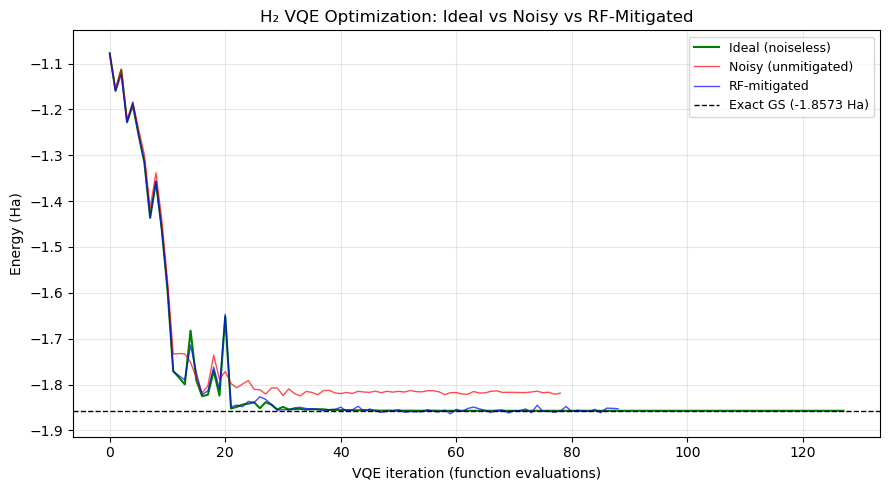

Saved: vqe_convergence.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(hist_ideal, color='green', linewidth=1.5, label='Ideal (noiseless)')
ax.plot(hist_noisy, color='red', alpha=0.7, linewidth=1, label='Noisy (unmitigated)')
ax.plot(hist_mitig, color='blue', alpha=0.7, linewidth=1, label='RF-mitigated')
ax.axhline(E_EXACT, color='black', linestyle='--', linewidth=1, label=f'Exact GS ({E_EXACT:.4f} Ha)')

ax.set_xlabel('VQE iteration (function evaluations)')
ax.set_ylabel('Energy (Ha)')
ax.set_title('H\u2082 VQE Optimization: Ideal vs Noisy vs RF-Mitigated')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Zoom y-axis around the ground state for clarity
y_min = min(min(hist_ideal), min(hist_mitig), E_EXACT) - 0.05
y_max = max(hist_noisy[0], hist_ideal[0], hist_mitig[0]) + 0.05
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('vqe_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vqe_convergence.png')

## 6. Energy Error Comparison

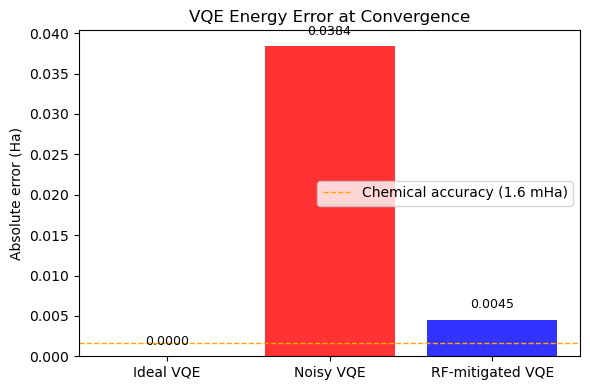

Noisy error:     0.0384 Ha
Mitigated error: 0.0045 Ha
Improvement:     8.5x


In [8]:
errors = {
    'Ideal VQE': abs(E_ideal - E_EXACT),
    'Noisy VQE': abs(E_noisy - E_EXACT),
    'RF-mitigated VQE': abs(E_mitig - E_EXACT),
}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(errors.keys(), errors.values(),
              color=['green', 'red', 'blue'], alpha=0.8)
ax.axhline(0.0016, color='orange', linestyle='--', linewidth=1,
           label='Chemical accuracy (1.6 mHa)')
ax.set_ylabel('Absolute error (Ha)')
ax.set_title('VQE Energy Error at Convergence')
ax.legend()

# Add value labels on bars
for bar, val in zip(bars, errors.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('vqe_errors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Noisy error:     {errors["Noisy VQE"]:.4f} Ha')
print(f'Mitigated error: {errors["RF-mitigated VQE"]:.4f} Ha')
print(f'Improvement:     {errors["Noisy VQE"]/errors["RF-mitigated VQE"]:.1f}x')

## 7. Evaluate at Multiple Points (Optional)

For a cleaner comparison, evaluate the energy at the **ideal optimal** $\theta^*$
using noisy and RF-corrected estimators. This isolates the correction quality
from the optimizer's convergence behavior.

Averages over 20 noisy evaluations to reduce shot noise variance.

In [10]:
N_EVAL = 20
print(f'Evaluating {N_EVAL} times at ideal theta* to average out shot noise...\n')

ideal_at_opt = ideal_cost(theta_ideal)

noisy_evals = [noisy_cost(theta_ideal) for _ in range(N_EVAL)]
mitig_evals = [mitigated_cost(theta_ideal) for _ in range(N_EVAL)]

noisy_mean = np.mean(noisy_evals)
noisy_std  = np.std(noisy_evals)
mitig_mean = np.mean(mitig_evals)
mitig_std  = np.std(mitig_evals)

print(f'At ideal theta*:')
print(f'  Exact:       {E_EXACT:.6f} Ha')
print(f'  Ideal VQE:   {ideal_at_opt:.6f} Ha')
print(f'  Noisy:       {noisy_mean:.6f} +/- {noisy_std:.4f} Ha  (bias: {noisy_mean - E_EXACT:+.4f})')
print(f'  RF-mitigated:{mitig_mean:.6f} +/- {mitig_std:.4f} Ha  (bias: {mitig_mean - E_EXACT:+.4f})')
print(f'\nBias reduction: {abs(noisy_mean - E_EXACT)/abs(mitig_mean - E_EXACT):.1f}x')

Evaluating 20 times at ideal theta* to average out shot noise...

At ideal theta*:
  Exact:       -1.857275 Ha
  Ideal VQE:   -1.857275 Ha
  Noisy:       -1.818585 +/- 0.0030 Ha  (bias: +0.0387)
  RF-mitigated:-1.858689 +/- 0.0033 Ha  (bias: -0.0014)

Bias reduction: 27.4x
